# Linear and Multiple Regression — Advanced Practice Within Lecture Scope

## Student Workbook

This notebook is based only on the concepts covered in the lecture:

- Preparing \(X\) and \(y\)
- Initializing parameters
- Making predictions
- Calculating prediction error
- Cost function
- Gradient Descent
- Learning rate
- Best-fit line
- Multiple Linear Regression
- Coefficient interpretation
- Vectorized form
- Regression evaluation
- `scikit-learn` workflow

The tasks are challenging, but they do not require concepts outside the lecture.

## General Instructions

For every task:

1. Show your calculations or code clearly.
2. Explain the result in words.
3. Do not use `scikit-learn` in the from-scratch tasks.
4. Use `scikit-learn` only when the task explicitly requests it.
5. Interpret the intercept, slope, coefficients, errors, and metrics.

# 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully.")

Libraries imported successfully.


# Task 1 — Compare Candidate Regression Lines

A model uses:

$$
\hat{y} = \theta_0 + \theta_1x
$$

You are given a small dataset and three candidate parameter pairs.

### Required

1. Calculate predictions for every candidate.
2. Calculate the error for every observation.
3. Calculate the cost:

$$
J(\theta_0,\theta_1)
=
\frac{1}{2m}
\sum_{i=1}^{m}
(\hat{y}^{(i)}-y^{(i)})^2
$$

4. Create a comparison table.
5. Select the candidate with the lowest cost.
6. Plot all candidate lines with the data.

In [2]:
task1_df = pd.DataFrame({
    "x": [1, 2, 3, 4, 5],
    "y": [7, 9, 13, 15, 18]
})

candidate_parameters = {
    "Candidate A": (0, 3),
    "Candidate B": (4, 2.5),
    "Candidate C": (6, 2)
}

display(task1_df)

,x,y
0,1,7
1,2,9
2,3,13
3,4,15
4,5,18


In [3]:
# Complete Task 1.
x = task1_df["x"].to_numpy(dtype=float)
y = task1_df["y"].to_numpy(dtype=float)
m = len(y)

rows = []

for name, (t0, t1) in candidate_parameters.items():
    preds = t0 + t1 * x
    errors = preds - y
    cost = np.sum(errors ** 2) / (2 * m)

    print(name, "predictions:", preds)
    print(name, "errors:", errors)
    print(name, "cost:", cost)

    rows.append({"candidate": name, "theta_0": t0, "theta_1": t1, "cost": cost})

comparison = pd.DataFrame(rows)
print("comparison between candidates:")
print(comparison)

best_candidate = comparison.loc[comparison["cost"].idxmin(), "candidate"]
print("\nlowest cost:", best_candidate)

Candidate A predictions: [ 3.  6.  9. 12. 15.]
Candidate A errors: [-4. -3. -4. -3. -3.]
Candidate A cost: 5.9
Candidate B predictions: [ 6.5  9.  11.5 14.  16.5]
Candidate B errors: [-0.5  0.  -1.5 -1.  -1.5]
Candidate B cost: 0.575
Candidate C predictions: [ 8. 10. 12. 14. 16.]
Candidate C errors: [ 1.  1. -1. -1. -2.]
Candidate C cost: 0.8
comparison between candidates:
     candidate  theta_0  theta_1   cost
0  Candidate A        0      3.0  5.900
1  Candidate B        4      2.5  0.575
2  Candidate C        6      2.0  0.800

lowest cost: Candidate B


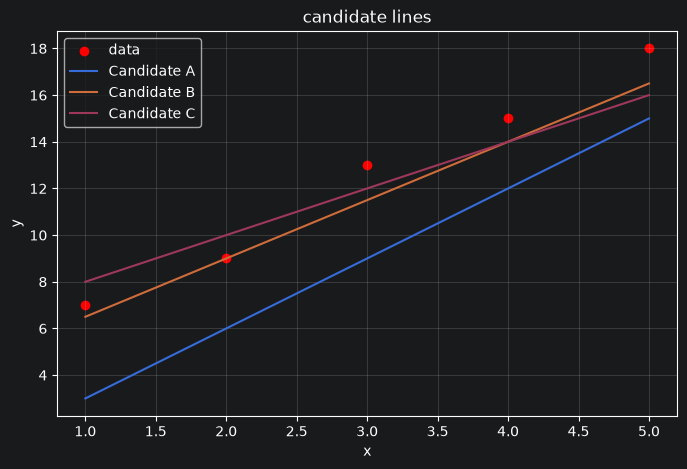

In [60]:
# plot
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color="red", label="data")

for name, (t0, t1) in candidate_parameters.items():
    plt.plot(x, t0 + t1 * x, label=name)

plt.xlabel("x")
plt.ylabel("y")
plt.title("candidate lines")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Interpretation Questions

1. Which candidate produced the lowest cost?
2. Did the best line pass through every point?
3. Why is the lowest-cost line considered the best among these candidates?

In [5]:
# Write your answers as comments.
# 1. candidate B. cost was 0.575, lowest of the three.

# 2. no. it missed most points a bit. only x=2 was exact.

# 3. cost measures total squared miss. lower cost = closer to all points at once. "best" here means best of these three, not the best line possible.

# Task 2 — Perform One Gradient Descent Update

Use the following equations:

Prediction:

$$
\hat{y}^{(i)} = \theta_0 + \theta_1x^{(i)}
$$

Gradients:

$$
\frac{\partial J}{\partial\theta_0}
=
\frac{1}{m}
\sum_{i=1}^{m}
(\hat{y}^{(i)}-y^{(i)})
$$

$$
\frac{\partial J}{\partial\theta_1}
=
\frac{1}{m}
\sum_{i=1}^{m}
(\hat{y}^{(i)}-y^{(i)})x^{(i)}
$$

Updates:

$$
\theta_0 := \theta_0 - \alpha \frac{\partial J}{\partial\theta_0}
$$

$$
\theta_1 := \theta_1 - \alpha \frac{\partial J}{\partial\theta_1}
$$

### Required

Start with:

- \(\theta_0 = 0\)
- \(\theta_1 = 0\)
- \(\alpha = 0.01\)

Then:

1. Calculate the initial predictions.
2. Calculate both gradients.
3. Update both parameters once.
4. Calculate the cost before and after the update.
5. Explain whether the update improved the model.

In [6]:
task2_df = pd.DataFrame({
    "x": [1, 2, 3, 4],
    "y": [5, 8, 11, 14]
})

display(task2_df)

,x,y
0,1,5
1,2,8
2,3,11
3,4,14


In [7]:
# Complete Task 2.
x2 = task2_df["x"].to_numpy(dtype=float)
y2 = task2_df["y"].to_numpy(dtype=float)
m2 = len(y2)

t0, t1 = 0.0, 0.0
alpha = 0.01

In [8]:
# initial predictions
preds = t0 + t1 * x2
errors = preds - y2
cost_before = np.sum(errors ** 2) / (2 * m2)

print("predictions:", preds)
print("errors:", errors)
print("cost:", cost_before)

predictions: [0. 0. 0. 0.]
errors: [ -5.  -8. -11. -14.]
cost: 50.75


In [9]:
# calculating gradients
grad_0 = np.mean(errors)
grad_1 = np.mean(errors * x2)
print("grad_0:", grad_0)
print("grad_1:", grad_1)

t0 = t0 - alpha * grad_0
t1 = t1 - alpha * grad_1
print("new theta_0:", t0)
print("new theta_1:", t1)

new_errors = (t0 + t1 * x2) - y2
cost_after = np.sum(new_errors ** 2) / (2 * m2)
print("cost after:", cost_after)

grad_0: -9.5
grad_1: -27.5
new theta_0: 0.095
new theta_1: 0.275
cost after: 42.63841875


### Interpretation Questions

1. Did the cost decrease after one update?
2. Why must both gradients be calculated before updating either parameter?
3. What would happen if the learning rate were zero?

In [10]:
# Write your answers as comments.
# 1. yes. before: 50.75 --> after: 42.64.

# 2. both gradients must come from the same old thetas.

# 3. nothing moves. alpha * gradient = 0, so thetas stay 0 forever and the cost never changes. no learning/

# Task 3 — Build Simple Linear Regression from Scratch

Build a complete Simple Linear Regression model without `scikit-learn`.

### Required Functions

1. `predict()`
2. `compute_cost()`
3. `compute_gradients()`
4. `gradient_descent()`

### Required Outputs

- Learned intercept
- Learned slope
- Final equation
- Cost history
- Best-fit line
- Prediction table
- MAE, MSE, RMSE, and \(R^2\)
- Prediction for \(x=7.5\)

In [11]:
task3_df = pd.DataFrame({
    "study_hours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "score": [45, 50, 56, 60, 65, 72, 78, 83, 88, 94]
})

display(task3_df)

,study_hours,score
0,1,45
1,2,50
2,3,56
3,4,60
4,5,65
5,6,72
6,7,78
7,8,83
8,9,88
9,10,94


### Hints

- Use NumPy arrays.
- Start with `theta_0 = 0` and `theta_1 = 0`.
- Try `learning_rate = 0.01`.
- Try `iterations = 2000`.
- Store the cost after every iteration.

In [12]:
# Complete task 3
# setup
x3 = task3_df["study_hours"].to_numpy(dtype=float)
y3 = task3_df["score"].to_numpy(dtype=float)

In [13]:
# 'model' helper functions

def predict(x_values, theta_0, theta_1):
    return theta_0 + theta_1 * x_values

def compute_error(x_values, y_values, theta_0, theta_1):
    return predict(x_values, theta_0, theta_1) - y_values

def compute_cost(x_values, y_values, theta_0, theta_1):
    errors = compute_error(x_values, y_values, theta_0, theta_1)
    return np.sum(errors ** 2) / (2 * len(y_values))

def compute_gradients(x_values, y_values, theta_0, theta_1):
    errors = compute_error(x_values, y_values, theta_0, theta_1)
    return np.mean(errors), np.mean(errors * x_values)

def gradient_descent(x_values, y_values, theta_0=0.0, theta_1=0.0, learning_rate=0.01, iterations=2000):
    cost_history = []

    for _ in range(iterations):
        g0, g1 = compute_gradients(x_values, y_values, theta_0, theta_1)
        theta_0 = theta_0 - learning_rate * g0
        theta_1 = theta_1 - learning_rate * g1
        cost_history.append(compute_cost(x_values, y_values, theta_0, theta_1))

    return theta_0, theta_1, cost_history

In [14]:
# training
b0, b1, cost_history = gradient_descent(x3, y3, learning_rate=0.01, iterations=2000)

print(f"intercept: {b0:.4f}")
print(f"slope:, {b1:.4f}")
print(f"equation: y_hat = {b0:.4f} + {b1:.4f}x")
print("final cost:", cost_history[-1])

intercept: 38.4408
slope:, 5.5531
equation: y_hat = 38.4408 + 5.5531x
final cost: 0.2316942729719665


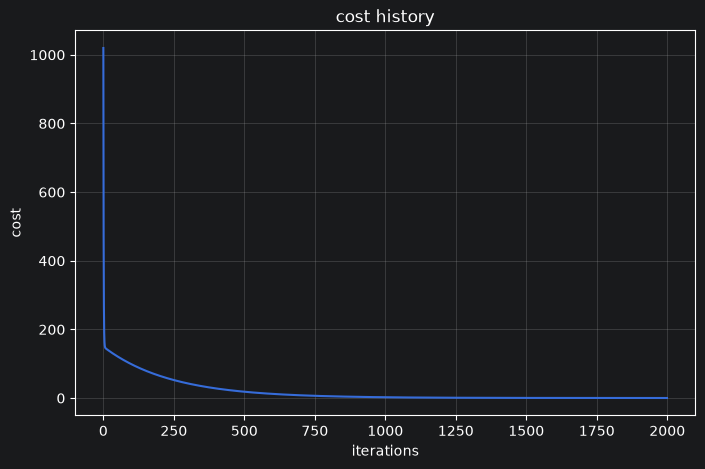

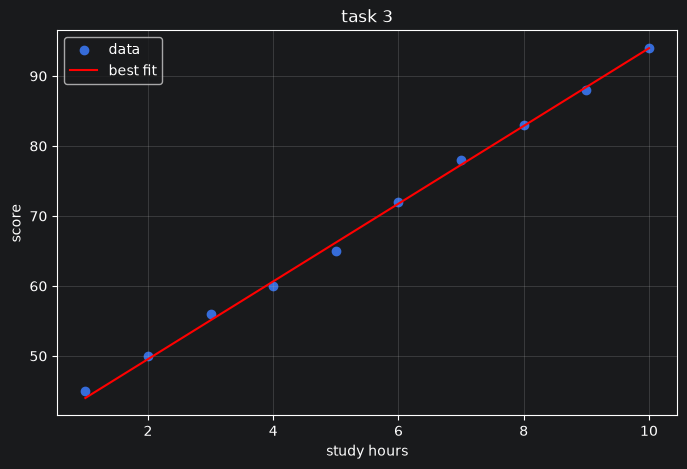

In [15]:
# plots

# cost history
plt.figure(figsize=(8, 5))
plt.plot(cost_history)
plt.xlabel("iterations")
plt.ylabel("cost")
plt.title("cost history")
plt.grid(alpha=0.3)
plt.show()

# predictions
preds3 = predict(x3, b0, b1)

plt.figure(figsize=(8, 5))
plt.scatter(x3, y3, label="data")
plt.plot(x3, preds3, color="red", label="best fit")
plt.xlabel("study hours")
plt.ylabel("score")
plt.title("task 3")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [16]:
# prediction table
table3 = pd.DataFrame({
    "study_hours": x3,
    "actual": y3,
    "predicted": preds3,
    "residual": y3 - preds3
})
display(table3)

,study_hours,actual,predicted,residual
0,1.0,45.0,43.993818,1.006182
1,2.0,50.0,49.546874,0.453126
2,3.0,56.0,55.099931,0.900069
3,4.0,60.0,60.652988,-0.652988
4,5.0,65.0,66.206044,-1.206044
5,6.0,72.0,71.759101,0.240899
6,7.0,78.0,77.312158,0.687842
7,8.0,83.0,82.865214,0.134786
8,9.0,88.0,88.418271,-0.418271
9,10.0,94.0,93.971328,0.028672


In [17]:
# mettrics

res = y3 - preds3
mae = np.mean(np.abs(res))
mse = np.mean(res ** 2)
rmse = np.sqrt(mse)
r2 = 1 - np.sum(res ** 2) / np.sum((y3 - np.mean(y3)) ** 2)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

print("\nprediction for x=7.5:", predict(7.5, b0, b1))

MAE : 0.5728879445151229
MSE : 0.463388545943933
RMSE: 0.6807264839448609
R2  : 0.998127647396081

prediction for x=7.5: 80.08868604208976


### Interpretation Questions

1. What does the learned slope mean?
2. Is the intercept practically meaningful?
3. Did the cost decrease smoothly?
4. Why does the best-fit line not need to pass through every point?

In [18]:
# Write your answers as comments.
# 1. learned slope = 5.55. one more study hours adds about 5.6 points.

# 2. not really. intercept 38.44 is the score at zero hours. no one studied zero hours, so it's outside our data. it just sets the line height.

# 3. yes. big drop early, then a slow flat tail. never went up.

# 4. it impossible, because normally the data points are not perfectly straight. one lime cannot hit them all.

# Task 4 — Learning Rate Experiment

Use the same dataset from Task 3.

Train the manual Gradient Descent model using:

- `learning_rate = 0.001`
- `learning_rate = 0.01`
- `learning_rate = 0.1`

Use the same number of iterations for all experiments.

### Required

1. Store the final cost for each learning rate.
2. Plot the cost history separately for each learning rate.
3. Identify stable, slow, or divergent training.
4. Create a comparison table.

In [19]:
# Complete Task 4 using your functions from Task 3.
learning_rates = [0.001, 0.01, 0.1]
iterations = 2000

results = {}
rows4 = []

for lr in learning_rates:
    b0_lr, b1_lr, hist = gradient_descent(x3, y3, learning_rate=lr, iterations=iterations)
    results[lr] = hist
    rows4.append({
        "learning_rate": lr,
        "final_theta_0": b0_lr,
        "final_theta_1": b1_lr,
        "final_cost": hist[-1]
    })

table4 = pd.DataFrame(rows4)
display(table4)

/var/folders/3s/jql1n_qx6r1d35xy8r4xn6sr0000gn/T/ipykernel_39930/1040721263.py:11: RuntimeWarning: overflow encountered in square
  return np.sum(errors ** 2) / (2 * len(y_values))
/Users/rmsaah/PycharmProjects/TuwaiqClasses/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Users/rmsaah/PycharmProjects/TuwaiqClasses/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/var/folders/3s/jql1n_qx6r1d35xy8r4xn6sr0000gn/T/ipykernel_39930/1040721263.py:23: RuntimeWarning: invalid value encountered in scalar subtract
  theta_1 = theta_1 - learning_rate * g1


,learning_rate,final_theta_0,final_theta_1,final_cost
0,0.001,14.399211,9.006398,65.048061
1,0.010,38.440761,5.553057,0.231694
2,0.100,NaN,NaN,NaN


/Users/rmsaah/PycharmProjects/TuwaiqClasses/.venv/lib/python3.13/site-packages/matplotlib/scale.py:375: RuntimeWarning: overflow encountered in exp
  return np.exp(values * np.log(self.base))


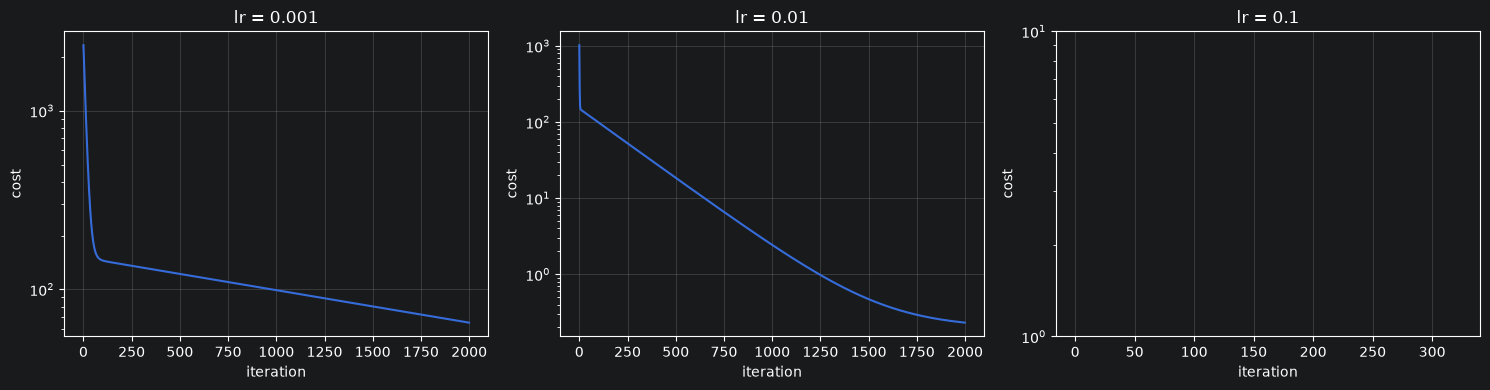

In [20]:
# one plot per learning rate
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, lr in zip(axes, learning_rates):
    ax.plot(results[lr])
    ax.set_title(f"lr = {lr}")
    ax.set_xlabel("iteration")
    ax.set_ylabel("cost")
    ax.set_yscale("log")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation Questions

1. Which learning rate converged fastest?
2. Which learning rate was too small or too large?
3. What pattern indicates divergence?
4. Why can the best learning rate depend on the scale of \(X\)?

In [21]:
# Write your answers as comments.
# 1. lr = 0.01. dropped fast and settled.

# 2. lr = 0.001 was too small, still crawling down at iteration 2000.
#    lr = 0.1 was too large, it blew up to infinity.

# 3. divergence = cost goes up every step, then inf or nan. each step overshoots the bottom and lands higher.

# 4. gradients include x. big x values make big gradients, so the same alpha takes a much bigger step. data with large x needs a smaller alpha, or scale the features first.

# Task 5 — Multiple Linear Regression by Manual Substitution

A house-price model is:

$$
\hat{y}
=
\theta_0
+
\theta_1x_1
+
\theta_2x_2
+
\theta_3x_3
$$

Where:

- \(x_1\): area in m²
- \(x_2\): number of bedrooms
- \(x_3\): property age in years

The learned parameters are:

- \(\theta_0 = 120\)
- \(\theta_1 = 3.5\)
- \(\theta_2 = 25\)
- \(\theta_3 = -2\)

Prices are measured in thousands.

### Required

1. Predict the price for each property.
2. Calculate residuals.
3. Interpret every coefficient.
4. Predict a new property with:
   - Area = 180
   - Bedrooms = 4
   - Age = 8
5. Explain “holding other features constant.”

In [22]:
task5_df = pd.DataFrame({
    "area_m2": [100, 140, 180, 220],
    "bedrooms": [2, 3, 4, 5],
    "property_age": [20, 12, 8, 4],
    "actual_price_thousands": [470, 650, 845, 1035]
})

theta_0 = 120
theta_1 = 3.5
theta_2 = 25
theta_3 = -2

display(task5_df)

,area_m2,bedrooms,property_age,actual_price_thousands
0,100,2,20,470
1,140,3,12,650
2,180,4,8,845
3,220,5,4,1035


In [23]:
# Complete Task 5.
pred5 = (
    theta_0
    + theta_1 * task5_df["area_m2"]
    + theta_2 * task5_df["bedrooms"]
    + theta_3 * task5_df["property_age"]
)

result5 = task5_df.copy()
result5["predicted_price"] = pred5
result5["residual"] = result5["actual_price_thousands"] - pred5

# theta_0 = 120: base price before any feature is counted.
#   not real. A house with 0 m2 does not exist.
# theta_1 = 3.5: each extra m2 adds 3.5 thousand.
# theta_2 = 25: each extra bedroom adds 25 thousand.
# theta_3 = -2: each extra year of age removes 2 thousand.

display(result5)

# new property
new_pred = theta_0 + theta_1 * 180 + theta_2 * 4 + theta_3 * 8
print("new property (180 m2, 4 bed, 8 yrs):", new_pred, "thousand")

# "Holding other features constant":
#   change one feature, freeze the rest.
#   3.5 means: same bedrooms, same age, add 1 m2 -> +3.5k.
#   real houses do not work that way. A bigger house usually has
#   more bedrooms too. The coefficient isolates one effect on paper.

,area_m2,bedrooms,property_age,actual_price_thousands,predicted_price,residual
0,100,2,20,470,480.0,-10.0
1,140,3,12,650,661.0,-11.0
2,180,4,8,845,834.0,11.0
3,220,5,4,1035,1007.0,28.0


new property (180 m2, 4 bed, 8 yrs): 834.0 thousand


### Interpretation Questions

1. What does the area coefficient mean?
2. Why is the property-age coefficient negative?
3. Can the size of coefficients be compared directly when units differ?
4. Does a negative coefficient prove causation?

In [24]:
# Write your answers as comments.
# 1. 3.5 thousand more per extra m2, other features unchanged.

# 2. older houses are worth less. wear, old design, repairs.

# 3. no. units differ. 25 per bedroom vs 3.5 per m2 looks bigger, but one m2 is a tiny step and one bedroom is a big step.

# 4. no. it only shows a pattern in this data. age may travel with other things we never measured, like location or condition.

# Task 6 — Vectorized Multiple Regression

Use the vectorized equation:

$$
\hat{y} = X\theta
$$

Include an intercept column of ones in \(X\).

### Required

1. Build the design matrix manually.
2. Build the parameter vector.
3. Calculate all predictions using matrix multiplication.
4. Verify one row using manual substitution.
5. Calculate residuals and MSE.
6. Explain why vectorization is useful.

In [25]:
task6_df = pd.DataFrame({
    "x1": [2, 4, 6, 8],
    "x2": [1, 3, 2, 5],
    "y": [14, 25, 31, 46]
})

theta = np.array([5, 3, 2])  # intercept, x1 coefficient, x2 coefficient

display(task6_df)

,x1,x2,y
0,2,1,14
1,4,3,25
2,6,2,31
3,8,5,46


In [26]:
# Complete Task 6.
x1 = task6_df["x1"].to_numpy(dtype=float)
x2 = task6_df["x2"].to_numpy(dtype=float)
y6 = task6_df["y"].to_numpy(dtype=float)

ones = np.ones(len(y6))

In [27]:
# design matrix
X = np.column_stack([ones, x1, x2])
print("X:\n", X)
print("X shape:", X.shape, " theta shape:", theta.shape)

X:
 [[1. 2. 1.]
 [1. 4. 3.]
 [1. 6. 2.]
 [1. 8. 5.]]
X shape: (4, 3)  theta shape: (3,)


In [28]:
# all predictions at once
y_hat = X @ theta
print("predictions:", y_hat)

predictions: [13. 23. 27. 39.]


In [29]:
# verify row 0 by hand
manual = theta[0] * 1 + theta[1] * x1[0] + theta[2] * x2[0]
print("row 0 manual:", manual, " matrix:", y_hat[0])

row 0 manual: 13.0  matrix: 13.0


In [30]:
# residuals and MSE
residuals = y6 - y_hat
mse6 = np.mean(residuals ** 2)

table6 = pd.DataFrame({
    "x1": x1, "x2": x2, "actual": y6,
    "predicted": y_hat, "residual": residuals
})
display(table6)
print("MSE:", mse6)

,x1,x2,actual,predicted,residual
0,2.0,1.0,14.0,13.0,1.0
1,4.0,3.0,25.0,23.0,2.0
2,6.0,2.0,31.0,27.0,4.0
3,8.0,5.0,46.0,39.0,7.0


MSE: 17.5


### Interpretation Questions

1. Why do we add a column of ones?
2. What are the dimensions of \(X\), \(	heta\), and \(\hat{y}\)?
3. How does matrix multiplication replace repeated manual calculations?

In [31]:
# Write your answers as comments.
# 1. the ones column pairs with theta_0. it makes the intercept behave like a normal coefficient, so one matrix multiply handles it too. without it we would add theta_0 separately.

# 2. X is (4, 3): 4 rows, 3 columns (ones, x1, x2). theta is (3,): one value per column. y_hat is (4,): one prediction per row. the inner numbers must match: (4, 3) @ (3,) --> (4,)

# 3. one @ replaces a loop over every row and every feature. numPy runs it in fast compiled code, and the formula stays the same no matter how many features you add.

# Task 7 — Simple Linear Regression with `scikit-learn`

Use `LinearRegression` to predict delivery time from distance.

### Required

1. Split the data.
2. Train the model.
3. Print `intercept_` and `coef_`.
4. Predict the test set.
5. Calculate MAE, MSE, RMSE, and R².
6. Create a residual table.
7. Plot the best-fit line.
8. Predict delivery time for 18 km.

In [32]:
task7_df = pd.DataFrame({
    "distance_km": [2, 4, 5, 7, 9, 11, 13, 15, 17, 20, 23, 26],
    "delivery_time_minutes": [12, 17, 20, 26, 31, 36, 42, 47, 52, 61, 68, 76]
})

display(task7_df)

,distance_km,delivery_time_minutes
0,2,12
1,4,17
2,5,20
3,7,26
4,9,31
5,11,36
6,13,42
7,15,47
8,17,52
9,20,61


In [33]:
# Complete Task 7.
X7 = task7_df[["distance_km"]]
y7 = task7_df["delivery_time_minutes"]

X7_train, X7_test, y7_train, y7_test = train_test_split(
    X7, y7, test_size=0.2, random_state=42
)
print("train:", len(X7_train), " test:", len(X7_test))

train: 9  test: 3


In [34]:
model7 = LinearRegression()
model7.fit(X7_train, y7_train)

print("intercept_:", model7.intercept_)
print("coef_[0]  :", model7.coef_[0])

intercept_: 6.846041055718494
coef_[0]  : 2.66715542521994


In [35]:
pred7 = model7.predict(X7_test)

mae7 = mean_absolute_error(y7_test, pred7)
mse7 = mean_squared_error(y7_test, pred7)
rmse7 = np.sqrt(mse7)
r2_7 = r2_score(y7_test, pred7)

print("MAE :", mae7)
print("MSE :", mse7)
print("RMSE:", rmse7)
print("R2  :", r2_7)

resid7 = pd.DataFrame({
    "distance_km": X7_test["distance_km"],
    "actual": y7_test,
    "predicted": pred7,
    "residual": y7_test - pred7
})
display(resid7.round(2))

MAE : 0.39393939393939686
MSE : 0.24211321425398127
RMSE: 0.492050011943889
R2  : 0.9996099142627487


,distance_km,actual,predicted,residual
10,23,68,68.19,-0.19
9,20,61,60.19,0.81
0,2,12,12.18,-0.18


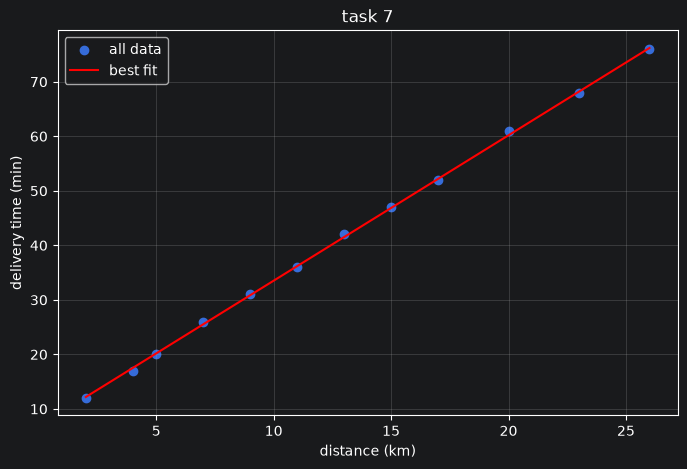

18 km -> 54.85483870967741 minutes


In [36]:
plt.figure(figsize=(8, 5))
plt.scatter(X7["distance_km"], y7, label="all data")
plt.plot(X7["distance_km"], model7.predict(X7), color="red", label="best fit")
plt.xlabel("distance (km)")
plt.ylabel("delivery time (min)")
plt.title("task 7")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("18 km ->", model7.predict(pd.DataFrame({"distance_km": [18]}))[0], "minutes")

### Interpretation Questions

1. What does `coef_[0]` mean?
2. Why are test metrics more meaningful than training metrics?
3. What does a positive residual mean when residual = actual − predicted?
4. Does `LinearRegression` expose a learning rate?

In [37]:
# Write your answers as comments.
# 1. coef_[0] = the slope. Minutes added per extra km.

# 2. Training metrics grade the model on rows it already saw. It can memorize those. Test rows are new, so they show whether it really generalizes.

# 3. Positive residual = actual was higher than predicted. The model was too optimistic. Real delivery took longer.

# 4. No. It solves the equations directly with linear algebra, in one shot. No steps, no alpha, no iterations.

# Task 8 — Multiple Linear Regression with `scikit-learn`

Predict employee performance using:

- Training hours
- Experience years
- Overtime hours

### Required

1. Train/test split.
2. Train Multiple Linear Regression.
3. Create a coefficient table.
4. Evaluate the model.
5. Predict a new employee.
6. Interpret all coefficients while holding other features constant.
7. Compare actual and predicted values.

In [38]:
task8_df = pd.DataFrame({
    "training_hours": [4, 8, 12, 5, 16, 20, 7, 14, 18, 10, 22, 25, 9, 13, 17, 21],
    "experience_years": [1, 2, 3, 1, 5, 6, 2, 4, 7, 3, 8, 9, 2, 5, 6, 8],
    "overtime_hours": [18, 15, 14, 20, 10, 8, 17, 12, 9, 15, 7, 6, 19, 11, 10, 7],
    "performance_score": [52, 58, 62, 50, 73, 81, 57, 69, 78, 64, 86, 91, 54, 71, 76, 87]
})

display(task8_df)

,training_hours,experience_years,overtime_hours,performance_score
0,4,1,18,52
1,8,2,15,58
2,12,3,14,62
3,5,1,20,50
4,16,5,10,73
5,20,6,8,81
6,7,2,17,57
7,14,4,12,69
8,18,7,9,78
9,10,3,15,64


In [39]:
# Complete Task 8.
features = ["training_hours", "experience_years", "overtime_hours"]

X8 = task8_df[features]
y8 = task8_df["performance_score"]

X8_train, X8_test, y8_train, y8_test = train_test_split(
    X8, y8, test_size=0.2, random_state=42
)
print("train:", len(X8_train), " test:", len(X8_test))

train: 12  test: 4


In [40]:
model8 = LinearRegression()
model8.fit(X8_train, y8_train)

print("intercept:", model8.intercept_)

intercept: 66.78817674679938


In [41]:
# Coefficient table
coef_table = pd.DataFrame({
    "feature": features,
    "coefficient": model8.coef_
})
display(coef_table.round(4))

,feature,coefficient
0,training_hours,0.2843
1,experience_years,2.5171
2,overtime_hours,-1.0329


In [42]:
# Evaluate
pred8 = model8.predict(X8_test)

print("MAE :", mean_absolute_error(y8_test, pred8))
print("MSE :", mean_squared_error(y8_test, pred8))
print("RMSE:", np.sqrt(mean_squared_error(y8_test, pred8)))
print("R2  :", r2_score(y8_test, pred8))

compare8 = pd.DataFrame({
    "actual": y8_test,
    "predicted": pred8,
    "residual": y8_test - pred8
})
display(compare8.round(2))

MAE : 0.7085624272585029
MSE : 0.8465623303247339
RMSE: 0.920088218772925
R2  : 0.9941891903538413


,actual,predicted,residual
0,52,51.85,0.15
1,58,58.60,-0.60
5,81,79.31,1.69
14,76,76.40,-0.40


In [43]:
# New employee
new_employee = pd.DataFrame({
    "training_hours": [15],
    "experience_years": [5],
    "overtime_hours": [12]
})
print("predicted score:", model8.predict(new_employee)[0])

predicted score: 71.24368904763816


In [44]:
# training_hours  +0.28 : one more training hour, same experience
#                         and overtime -> +0.28 points.
# experience_years +2.52: one more year, same training and
#                         overtime -> +2.52 points.
# overtime_hours  -1.03 : one more overtime hour, same training
#                         and experience -> -1.03 points.
# intercept 66.79: score with zero of everything. Not real.
#                  Nobody in the data has zero.

### Interpretation Questions

1. Which coefficient is positive and which is negative?
2. What does the overtime coefficient mean?
3. Why must coefficient interpretation include “holding other variables constant”?
4. Can we rank importance using raw coefficient size alone?

In [45]:
# Write your answers as comments.
# 1. Positive: training_hours (0.28) and experience_years (2.52). Negative: overtime_hours (-1.03).

# 2. Each extra overtime hour drops the score by about 1.03, holding training and experience fixed. More overtime goes with worse performance here. Likely tiredness or burnout.

# 3. The features move together in this data. People with more experience also train more and do less overtime. Without "holding others constant" you would credit one feature for an effect the others share.

# 4. No. Units differ. 2.52 per year vs 0.28 per hour is not a fair race. One year is a big step, one hour is a small one. To rank fairly, scale the features first.

# Task 9 — Debugging Regression Training

For each case below, explain the most likely problem and the correct action.

### Case A
The cost starts at 500 and becomes:

`500, 900, 1800, 4200, 10000`

### Case B
The cost becomes:

`500, 499.8, 499.6, 499.4, 499.2`

after many iterations.

### Case C
Training R² is high, but test R² is much lower.

### Case D
All predictions are systematically lower than actual values.

### Case E
The slope is positive, but a student claims this proves that \(X\) causes \(Y\).

In [46]:
# Write your diagnosis and recommendation for each case.

# Case A: Cost goes UP each step. Diverging.
#   Cause: learning rate too large. Every step overshoots the bottom and lands higher on the other side.
#   Fix: lower alpha (0.1 -> 0.01 -> 0.001). Scale the features if x values are large.

# Case B: Cost barely moves. 0.2 per step after many iterations.
#   Cause: learning rate too small. Steps are tiny, so it crawls.
#   Fix: raise alpha, or run far more iterations. Check the cost is still falling and not just flat at the bottom already.

# Case C: Train R2 high, test R2 low. Overfitting.
#   Cause: the model learned noise in the training rows instead of the real pattern. Often too few rows, too many features.
#   Fix: more data, fewer features, simpler model, or use cross-validation to check honestly.

# Case D: Every prediction is too low. Biased, not random.
#   Cause: the intercept is wrong or missing. Common bug: no column of ones in X, so theta_0 is forced to zero. Or training stopped before it converged.
#   Fix: add the ones column, confirm theta_0 is being learned, train longer. Residuals should sit on both sides of zero.

# Case E: Positive slope does not prove X causes Y.
#   Cause: correlation is not causation. Something we never measured may drive both.
#   Fix: say "X and Y move together in this data". To claim cause you need a controlled experiment.

# Final Challenge — Complete Regression Workflow

Choose either Simple or Multiple Linear Regression.

Your analysis must include:

1. Problem definition
2. Feature(s) and target
3. Visualization
4. Train/test split
5. Model training
6. Intercept and coefficient interpretation
7. Predictions
8. MAE, MSE, RMSE, and R²
9. Residual table
10. Best-fit line if applicable
11. Three insights
12. Two limitations
13. Final conclusion

In [47]:
# Complete your final challenge here.
# 1. problem definition
# predict employee performance score from work habits. regression because the target is a continuous number.

In [48]:
# 2. features and target
fc_features = ["training_hours", "experience_years", "overtime_hours"]
fc_target = "performance_score"

fc_X = task8_df[fc_features]
fc_y = task8_df[fc_target]

print("X shape:", fc_X.shape, " y shape:", fc_y.shape)
print("\nmissing values:")
print(task8_df.isna().sum())
display(task8_df.describe().round(2))

X shape: (16, 3)  y shape: (16,)

missing values:
training_hours       0
experience_years     0
overtime_hours       0
performance_score    0
dtype: int64


,training_hours,experience_years,overtime_hours,performance_score
count,16.00,16.00,16.00,16.00
mean,13.81,4.50,12.38,69.31
std,6.38,2.63,4.57,13.17
min,4.00,1.00,6.00,50.00
25%,8.75,2.00,8.75,57.75
50%,13.50,4.50,11.50,70.00
75%,18.50,6.25,15.50,78.75
max,25.00,9.00,20.00,91.00


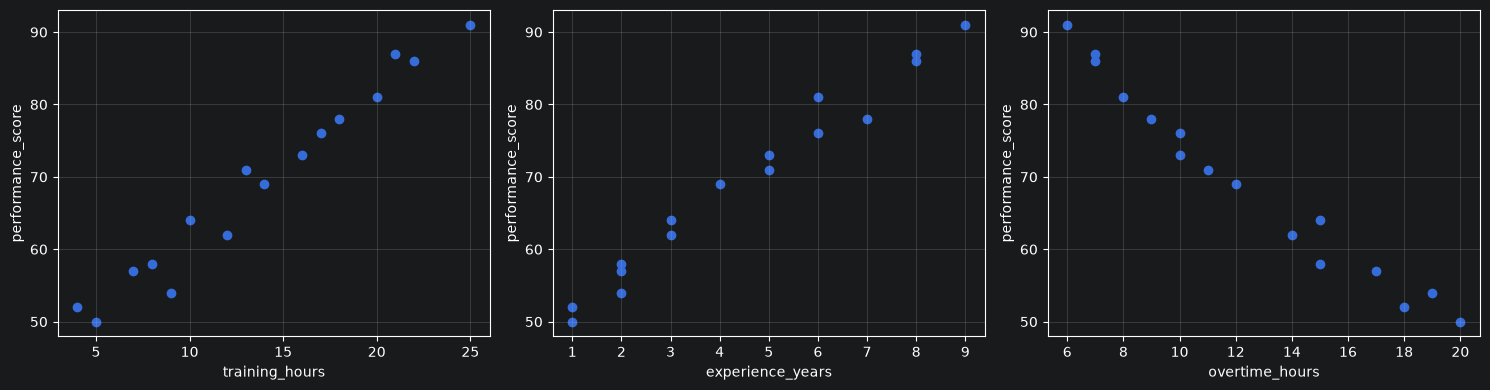

In [49]:
# 3. visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, f in zip(axes, fc_features):
    ax.scatter(task8_df[f], fc_y)
    ax.set_xlabel(f)
    ax.set_ylabel(fc_target)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [50]:
# 4. train/test split
fc_X_train, fc_X_test, fc_y_train, fc_y_test = train_test_split(
    fc_X, fc_y, test_size=0.2, random_state=42
)

print("train:", len(fc_X_train), " test:", len(fc_X_test))

train: 12  test: 4


In [51]:
# 5. model training
fc_model = LinearRegression()
fc_model.fit(fc_X_train, fc_y_train)

print("model trained")

model trained


In [52]:
# 6. intercept and coefficients
print("intercept:", fc_model.intercept_)

fc_coef_table = pd.DataFrame({
    "feature": fc_features,
    "coefficient": fc_model.coef_
})
display(fc_coef_table.round(4))

# training_hours +0.28: one more training hour --> +0.28 points
# experience_years +2.52: one more year --> +2.52 points
# overtime_hours -1.03: one more overtime hour --> -1.03 points
# each one holds the other features constant.
# intercept 66.79 is the score with zero of everything. not real, nobody in the data has zero.

intercept: 66.78817674679938


,feature,coefficient
0,training_hours,0.2843
1,experience_years,2.5171
2,overtime_hours,-1.0329


In [53]:
# 7. predictions
fc_pred = fc_model.predict(fc_X_test)
print("predictions:", fc_pred)

predictions: [51.85082474 58.60372436 79.31376169 76.39511177]


In [54]:
# 8. metrics
fc_mse = mean_squared_error(fc_y_test, fc_pred)

print("MAE :", mean_absolute_error(fc_y_test, fc_pred))
print("MSE :", fc_mse)
print("RMSE:", np.sqrt(fc_mse))
print("R2  :", r2_score(fc_y_test, fc_pred))

MAE : 0.7085624272585029
MSE : 0.8465623303247339
RMSE: 0.920088218772925
R2  : 0.9941891903538413


In [55]:
# 9. residual table
fc_resid = pd.DataFrame({
    "actual": fc_y_test,
    "predicted": fc_pred,
    "residual": fc_y_test - fc_pred
})
display(fc_resid.round(2))

,actual,predicted,residual
0,52,51.85,0.15
1,58,58.60,-0.60
5,81,79.31,1.69
14,76,76.40,-0.40


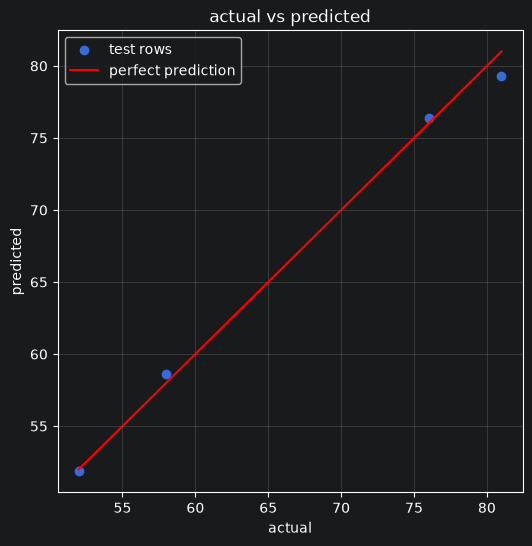

In [56]:
# 10. best fit line
# no single line with 3 features, so plot actual vs predicted instead
plt.figure(figsize=(6, 6))
plt.scatter(fc_y_test, fc_pred, label="test rows")
plt.plot([fc_y_test.min(), fc_y_test.max()],
         [fc_y_test.min(), fc_y_test.max()],
         color="red", label="perfect prediction")
plt.xlabel("actual")
plt.ylabel("predicted")
plt.title("actual vs predicted")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [57]:
# 11. three insights
# 1. experience matters most per unit. 2.52 per year vs 0.28 per training hour.

# 2. overtime is negative. more overtime goes with lower scores.

# 3. the fit is strong. test R2 0.994 and RMSE 0.92, so off by about 1 point on a 50 to 91 scale.

In [58]:
# 12. two limitations
# 1. only 16 rows and 4 test rows. change the split and the metrics move a lot.

# 2. the features move together. more experience comes with more training and less overtime, so the model cannot cleanly separate them.

In [59]:
# 13. final conclusion
# performance goes up with experience and training, and down with overtime.
# the fit looks strong but the data is tiny and the features overlap.
# this is a pattern, not a cause. not enough to make real decisions about people.